## **Problem statement**

Analyze XYZ Co.'s sales data from 2014–2018 to identify key revenue and profit drivers across products, channels, and regions. Uncover seasonal trends and outliers, 
and evaluate performance against budget targets. Use these insights to optimize pricing strategies, promotional activities, and market expansion efforts to achieve sustainable growth and reduce concentration risk.

In [3]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

In [4]:
df_1 = pd.read_excel("C:/Users/Startklar/DATA/PROJECTS_KN/Regional Sales Performance/data/Regional Sales Dataset.xlsx", sheet_name="Sales Orders")
df_2 = pd.read_excel("C:/Users/Startklar/DATA/PROJECTS_KN/Regional Sales Performance/data/Regional Sales Dataset.xlsx", sheet_name="Customers")
df_3 = pd.read_excel("C:/Users/Startklar/DATA/PROJECTS_KN/Regional Sales Performance/data/Regional Sales Dataset.xlsx", sheet_name="Regions")
df_4 = pd.read_excel("C:/Users/Startklar/DATA/PROJECTS_KN/Regional Sales Performance/data/Regional Sales Dataset.xlsx", sheet_name="State Regions")
df_5 = pd.read_excel("C:/Users/Startklar/DATA/PROJECTS_KN/Regional Sales Performance/data/Regional Sales Dataset.xlsx", sheet_name="Products")
df_6 = pd.read_excel("C:/Users/Startklar/DATA/PROJECTS_KN/Regional Sales Performance/data/Regional Sales Dataset.xlsx", sheet_name="2017 Budgets")



In [5]:
list(df_1)

['OrderNumber',
 'OrderDate',
 'Customer Name Index',
 'Channel',
 'Currency Code',
 'Warehouse Code',
 'Delivery Region Index',
 'Product Description Index',
 'Order Quantity',
 'Unit Price',
 'Line Total',
 'Total Unit Cost']

In [6]:
list(df_2)

['Customer Index', 'Customer Names']

In [7]:
list(df_3)

['id',
 'name',
 'county',
 'state_code',
 'state',
 'type',
 'latitude',
 'longitude',
 'area_code',
 'population',
 'households',
 'median_income',
 'land_area',
 'water_area',
 'time_zone']

In [8]:
list(df_4)

['Column1', 'Column2', 'Column3']

In [9]:
list(df_5)

['Index', 'Product Name']

In [10]:
list(df_6)

['Product Name', '2017 Budgets']

In [11]:
new_header = df_4.iloc[0]     
df_4 = df_4[1:]               
df_4.columns = new_header     
df_4 = df_4.reset_index(drop=True)


In [12]:
df = (df_1
      .merge(df_2, how='left',
             left_on='Customer Name Index', right_on='Customer Index')

      .merge(df_5, how='left',
             left_on='Product Description Index', right_on='Index')

      .merge(df_3, how='left',
             left_on='Delivery Region Index', right_on='id')

      .merge(df_4, how='left',
             left_on='state_code', right_on='State Code')

      .merge(df_6, how='left',
             on='Product Name')
     )

In [13]:
df.head()

,OrderNumber,OrderDate,Customer Name Index,Channel,Currency Code,Warehouse Code,Delivery Region Index,Product Description Index,Order Quantity,Unit Price,...,population,households,median_income,land_area,water_area,time_zone,State Code,State,Region,2017 Budgets
0,SO - 000225,2014-01-01,126,Wholesale,USD,AXW291,364,27,6,2499.1,...,145674,52798,36466,268318796,13908113,America/New York,GA,Georgia,South,964940.231
1,SO - 0003378,2014-01-01,96,Distributor,USD,AXW291,488,20,11,2351.7,...,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,IN,Indiana,Midwest,2067108.120
2,SO - 0005126,2014-01-01,8,Wholesale,USD,AXW291,155,26,6,978.2,...,79510,26020,124759,62489257,386195,America/Los Angeles,CA,California,West,5685138.270
3,SO - 0005614,2014-01-01,42,Export,USD,AXW291,473,7,7,2338.3,...,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,IN,Indiana,Midwest,889737.555
4,SO - 0005781,2014-01-01,73,Wholesale,USD,AXW291,256,8,8,2291.4,...,58007,24141,63158,70972793,720300,America/New York,CT,Connecticut,Northeast,1085037.329


In [14]:
df.shape

(64104, 35)

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   OrderNumber                64104 non-null  str           
 1   OrderDate                  64104 non-null  datetime64[us]
 2   Customer Name Index        64104 non-null  int64         
 3   Channel                    64104 non-null  str           
 4   Currency Code              64104 non-null  str           
 5   Warehouse Code             64104 non-null  str           
 6   Delivery Region Index      64104 non-null  int64         
 7   Product Description Index  64104 non-null  int64         
 8   Order Quantity             64104 non-null  int64         
 9   Unit Price                 64104 non-null  float64       
 10  Line Total                 64104 non-null  float64       
 11  Total Unit Cost            64104 non-null  float64       
 12  Customer Index 

In [16]:
df.duplicated().sum()


np.int64(0)

In [17]:
df.columns[df.columns.duplicated()]

Index([], dtype='str')

# Cleaning & Feature Engineering

In [18]:
df.columns

Index(['OrderNumber', 'OrderDate', 'Customer Name Index', 'Channel',
       'Currency Code', 'Warehouse Code', 'Delivery Region Index',
       'Product Description Index', 'Order Quantity', 'Unit Price',
       'Line Total', 'Total Unit Cost', 'Customer Index', 'Customer Names',
       'Index', 'Product Name', 'id', 'name', 'county', 'state_code', 'state',
       'type', 'latitude', 'longitude', 'area_code', 'population',
       'households', 'median_income', 'land_area', 'water_area', 'time_zone',
       'State Code', 'State', 'Region', '2017 Budgets'],
      dtype='str')

In [19]:
df.shape

(64104, 35)

In [20]:
df = df.drop(columns=[
    'Customer Name Index',
    'Customer Index',
    'Product Description Index',
    'Index',
    'Delivery Region Index',
    'id',
    'State Code'
])

In [21]:
df.shape

(64104, 28)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderNumber      64104 non-null  str           
 1   OrderDate        64104 non-null  datetime64[us]
 2   Channel          64104 non-null  str           
 3   Currency Code    64104 non-null  str           
 4   Warehouse Code   64104 non-null  str           
 5   Order Quantity   64104 non-null  int64         
 6   Unit Price       64104 non-null  float64       
 7   Line Total       64104 non-null  float64       
 8   Total Unit Cost  64104 non-null  float64       
 9   Customer Names   64104 non-null  str           
 10  Product Name     64104 non-null  str           
 11  name             64104 non-null  str           
 12  county           64104 non-null  str           
 13  state_code       64104 non-null  str           
 14  state            64104 non-null  str           
 

In [23]:
df.memory_usage(deep=True)

Index                  132
OrderNumber        3904950
OrderDate           512832
Channel            3729348
Currency Code      3333408
Warehouse Code     3525720
Order Quantity      512832
Unit Price          512832
Line Total          512832
Total Unit Cost     512832
Customer Names     3924474
Product Name       3762132
name               3755220
county             4208688
state_code         3269304
state              3682628
type               3436644
latitude            512832
longitude           512832
area_code           512832
population          512832
households          512832
median_income       512832
land_area           512832
water_area          512832
time_zone          4211837
State              3682628
Region             3517824
2017 Budgets        512832
dtype: int64

In [24]:
categorical_cols = [
    'Channel', 
    'Warehouse Code', 
    'Currency Code',
    'state', 
    'Region', 
    'Product Name',
    'name',
    'county',
    'type',
    'time_zone',
    'State'
]

df[categorical_cols] = df[categorical_cols].astype('category')

In [25]:
df.memory_usage(deep=True)

Index                  132
OrderNumber        3904950
OrderDate           512832
Channel              64277
Currency Code        64156
Warehouse Code       64324
Order Quantity      512832
Unit Price          512832
Line Total          512832
Total Unit Cost     512832
Customer Names     3924474
Product Name         65865
name                182292
county              156311
state_code         3269304
state                66817
type                 64823
latitude            512832
longitude           512832
area_code           512832
population          512832
households          512832
median_income       512832
land_area           512832
water_area          512832
time_zone            64707
State                66817
Region               64325
2017 Budgets        512832
dtype: int64

In [26]:
df.dtypes

OrderNumber                   str
OrderDate          datetime64[us]
Channel                  category
Currency Code            category
Warehouse Code           category
Order Quantity              int64
Unit Price                float64
Line Total                float64
Total Unit Cost           float64
Customer Names                str
Product Name             category
name                     category
county                   category
state_code                    str
state                    category
type                     category
latitude                  float64
longitude                 float64
area_code                   int64
population                  int64
households                  int64
median_income               int64
land_area                   int64
water_area                  int64
time_zone                category
State                    category
Region                   category
2017 Budgets              float64
dtype: object

In [27]:

df[categorical_cols]

,Channel,Warehouse Code,Currency Code,state,Region,Product Name,name,county,type,time_zone,State
0,Wholesale,AXW291,USD,Georgia,South,Product 27,Savannah,Chatham County,City,America/New York,Georgia
1,Distributor,AXW291,USD,Indiana,Midwest,Product 20,Greenwood,Johnson County,City,America/Indiana/Indianapolis,Indiana
2,Wholesale,AXW291,USD,California,West,Product 26,Pleasanton,Alameda County,City,America/Los Angeles,California
3,Export,AXW291,USD,Indiana,Midwest,Product 7,Bloomington,Monroe County,City,America/Indiana/Indianapolis,Indiana
4,Wholesale,AXW291,USD,Connecticut,Northeast,Product 8,Manchester,Hartford County,Town,America/New York,Connecticut
...,...,...,...,...,...,...,...,...,...,...,...
64099,Wholesale,AXW291,USD,Pennsylvania,Northeast,Product 26,Levittown,Bucks County,CDP,America/New York,Pennsylvania
64100,Export,NXH382,USD,Illinois,Midwest,Product 21,Palatine,Cook County,Village,America/Chicago,Illinois
64101,Distributor,AXW291,USD,Florida,South,Product 13,Margate,Broward County,City,America/New York,Florida
64102,Distributor,AXW291,USD,New York,Northeast,Product 20,Cheektowaga,Erie County,Town,America/New York,New York


In [28]:
df.isnull().sum()   

OrderNumber        0
OrderDate          0
Channel            0
Currency Code      0
Warehouse Code     0
Order Quantity     0
Unit Price         0
Line Total         0
Total Unit Cost    0
Customer Names     0
Product Name       0
name               0
county             0
state_code         0
state              0
type               0
latitude           0
longitude          0
area_code          0
population         0
households         0
median_income      0
land_area          0
water_area         0
time_zone          0
State              0
Region             0
2017 Budgets       0
dtype: int64

In [29]:
# # convert all columns to lower case for consistency and easier access
df.columns = df.columns.str.lower()
df.columns.values 

<StringArray>
[    'ordernumber',       'orderdate',         'channel',   'currency code',
  'warehouse code',  'order quantity',      'unit price',      'line total',
 'total unit cost',  'customer names',    'product name',            'name',
          'county',      'state_code',           'state',            'type',
        'latitude',       'longitude',       'area_code',      'population',
      'households',   'median_income',       'land_area',      'water_area',
       'time_zone',           'state',          'region',    '2017 budgets']
Length: 28, dtype: str

In [30]:
# df.describe()

In [31]:
df.describe(include='all')

,ordernumber,orderdate,channel,currency code,warehouse code,order quantity,unit price,line total,total unit cost,customer names,...,area_code,population,households,median_income,land_area,water_area,time_zone,state,region,2017 budgets
count,64104,64104,64104,64104,64104,64104.000000,64104.000000,64104.000000,64104.000000,64104,...,64104.000000,6.410400e+04,6.410400e+04,64104.000000,6.410400e+04,6.410400e+04,64104,64104,64104,6.410400e+04
unique,10684,NaN,3,1,4,NaN,NaN,NaN,NaN,175,...,NaN,NaN,NaN,NaN,NaN,NaN,9,47,4,NaN
top,SO - 000225,NaN,Wholesale,USD,AXW291,NaN,NaN,NaN,NaN,Kare Corp,...,NaN,NaN,NaN,NaN,NaN,NaN,America/New York,California,West,NaN
freq,6,NaN,34596,64104,30204,NaN,NaN,NaN,NaN,540,...,NaN,NaN,NaN,NaN,NaN,NaN,21848,12000,19540,NaN
mean,NaN,2016-01-29 01:28:20.935979,NaN,NaN,NaN,8.441689,2284.380803,19280.682937,1432.083899,NaN,...,610.927945,1.590968e+05,5.702520e+04,59396.944325,1.278377e+08,1.287047e+07,NaN,NaN,NaN,2.998558e+06
min,NaN,2014-01-01 00:00:00,NaN,NaN,NaN,5.000000,167.500000,837.500000,68.675000,NaN,...,202.000000,5.013800e+04,0.000000e+00,0.000000,2.575149e+06,0.000000e+00,NaN,NaN,NaN,5.944716e+05
25%,NaN,2015-01-13 00:00:00,NaN,NaN,NaN,6.000000,1031.800000,8019.900000,606.216000,NaN,...,405.000000,6.106800e+04,2.263900e+04,43163.000000,4.865395e+07,2.807360e+05,NaN,NaN,NaN,1.672229e+06
50%,NaN,2016-01-27 00:00:00,NaN,NaN,NaN,8.000000,1855.900000,14023.100000,1084.495500,NaN,...,626.000000,8.329800e+04,2.951800e+04,53587.500000,8.434784e+07,1.264402e+06,NaN,NaN,NaN,3.016489e+06
75%,NaN,2017-02-13 00:00:00,NaN,NaN,NaN,10.000000,3606.275000,27416.400000,2046.933750,NaN,...,832.000000,1.286670e+05,4.540900e+04,71897.000000,1.283868e+08,4.850146e+06,NaN,NaN,NaN,3.925425e+06
max,NaN,2018-02-28 00:00:00,NaN,NaN,NaN,12.000000,6566.000000,78711.600000,5498.556000,NaN,...,979.000000,8.550405e+06,3.113535e+06,149837.000000,1.935873e+09,8.521186e+08,NaN,NaN,NaN,5.685138e+06


In [32]:
df.columns

Index(['ordernumber', 'orderdate', 'channel', 'currency code',
       'warehouse code', 'order quantity', 'unit price', 'line total',
       'total unit cost', 'customer names', 'product name', 'name', 'county',
       'state_code', 'state', 'type', 'latitude', 'longitude', 'area_code',
       'population', 'households', 'median_income', 'land_area', 'water_area',
       'time_zone', 'state', 'region', '2017 budgets'],
      dtype='str')

In [33]:
df['time_zone'].value_counts()

time_zone
America/New York                21848
America/Chicago                 18170
America/Los Angeles             15019
America/Denver                   2991
America/Indiana/Indianapolis     2270
America/Detroit                  2039
America/Phoenix                  1254
America/Boise                     387
America/Kentucky/Louisville       126
Name: count, dtype: int64

In [34]:
# blank out budgets for 2017
df.loc[df['orderdate'].dt.year == 2017, '2017 budgets'] = np.nan

# line total is revenue
df[['orderdate','product name','line total','2017 budgets']].tail(20)

,orderdate,product name,line total,2017 budgets
64084,2018-02-28,Product 15,9882.5,3299478.315
64085,2018-02-28,Product 8,42819.7,1085037.329
64086,2018-02-28,Product 4,17487.0,2885560.824
64087,2018-02-28,Product 26,68688.4,5685138.270
64088,2018-02-28,Product 17,46310.4,2119616.824
64089,2018-02-28,Product 13,39818.1,3720639.645
64090,2018-02-28,Product 26,12622.8,5685138.270
64091,2018-02-28,Product 15,15436.8,3299478.315
64092,2018-02-28,Product 6,1608.0,1672229.416
64093,2018-02-28,Product 18,1608.0,2309499.045


In [35]:
df.to_csv("final.csv", index=False)

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 28 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   ordernumber      64104 non-null  str           
 1   orderdate        64104 non-null  datetime64[us]
 2   channel          64104 non-null  category      
 3   currency code    64104 non-null  category      
 4   warehouse code   64104 non-null  category      
 5   order quantity   64104 non-null  int64         
 6   unit price       64104 non-null  float64       
 7   line total       64104 non-null  float64       
 8   total unit cost  64104 non-null  float64       
 9   customer names   64104 non-null  str           
 10  product name     64104 non-null  category      
 11  name             64104 non-null  category      
 12  county           64104 non-null  category      
 13  state_code       64104 non-null  str           
 14  state            64104 non-null  category      
 

In [37]:
df.isnull().sum()

ordernumber            0
orderdate              0
channel                0
currency code          0
warehouse code         0
order quantity         0
unit price             0
line total             0
total unit cost        0
customer names         0
product name           0
name                   0
county                 0
state_code             0
state                  0
type                   0
latitude               0
longitude              0
area_code              0
population             0
households             0
median_income          0
land_area              0
water_area             0
time_zone              0
state                  0
region                 0
2017 budgets       15263
dtype: int64

In [38]:
df_2017 =df[df["orderdate"].dt.year==2017]

In [39]:
df.isnull().sum()

ordernumber            0
orderdate              0
channel                0
currency code          0
warehouse code         0
order quantity         0
unit price             0
line total             0
total unit cost        0
customer names         0
product name           0
name                   0
county                 0
state_code             0
state                  0
type                   0
latitude               0
longitude              0
area_code              0
population             0
households             0
median_income          0
land_area              0
water_area             0
time_zone              0
state                  0
region                 0
2017 budgets       15263
dtype: int64

In [40]:
df.columns[df.columns.isna()]

Index([], dtype='str')

In [41]:
df.isnull().sum()

ordernumber            0
orderdate              0
channel                0
currency code          0
warehouse code         0
order quantity         0
unit price             0
line total             0
total unit cost        0
customer names         0
product name           0
name                   0
county                 0
state_code             0
state                  0
type                   0
latitude               0
longitude              0
area_code              0
population             0
households             0
median_income          0
land_area              0
water_area             0
time_zone              0
state                  0
region                 0
2017 budgets       15263
dtype: int64

In [42]:
df_2017.head()

,ordernumber,orderdate,channel,currency code,warehouse code,order quantity,unit price,line total,total unit cost,customer names,...,area_code,population,households,median_income,land_area,water_area,time_zone,state,region,2017 budgets
46363,SO - 0002544,2017-01-01,Wholesale,USD,NXH382,6,1239.5,7437.0,1028.785,NCS Group,...,551,69156,23029,41107,3333346,0,America/New York,New Jersey,Northeast,NaN
46364,SO - 0006431,2017-01-01,Wholesale,USD,NXH382,5,1829.1,9145.5,1207.206,Epic Group,...,970,60358,24290,45358,101735554,921925,America/Denver,Colorado,West,NaN
46365,SO - 0007491,2017-01-01,Wholesale,USD,NXH382,9,2412.0,21708.0,1664.280,State Ltd,...,424,111666,36667,42044,23485845,63502,America/Los Angeles,California,West,NaN
46366,SO - 0008741,2017-01-01,Wholesale,USD,GUT930,8,904.5,7236.0,750.735,Fivebridge Ltd,...,563,58799,23901,47450,78952077,2802123,America/Chicago,Iowa,Midwest,NaN
46367,SO - 0009295,2017-01-01,Wholesale,USD,NXH382,12,1112.2,13346.4,811.906,Tagfeed Ltd,...,352,100270,39038,41308,154983928,6194314,America/New York,Florida,South,NaN


In [43]:
df["2017 budgets"].value_counts

<bound method IndexOpsMixin.value_counts of 0         964940.231
1        2067108.120
2        5685138.270
3         889737.555
4        1085037.329
            ...     
64099    5685138.270
64100     959899.218
64101    3720639.645
64102    2067108.120
64103    3299478.315
Name: 2017 budgets, Length: 64104, dtype: float64>

In [44]:
df['2017 budgets'].isnull().sum()

np.int64(15263)

In [45]:
df['2017 budgets'].isnull().mean() * 100

np.float64(23.809746661674776)

In [46]:
df['2017 budgets'] = df['2017 budgets'].fillna(df['2017 budgets'].median())

In [47]:
df.isnull().sum()

ordernumber        0
orderdate          0
channel            0
currency code      0
warehouse code     0
order quantity     0
unit price         0
line total         0
total unit cost    0
customer names     0
product name       0
name               0
county             0
state_code         0
state              0
type               0
latitude           0
longitude          0
area_code          0
population         0
households         0
median_income      0
land_area          0
water_area         0
time_zone          0
state              0
region             0
2017 budgets       0
dtype: int64

In [48]:
df =df.rename(columns={"line total":"revenue", "total unit cost":"cost", "2017 budgets":"budget"})

In [49]:
df.head()

,ordernumber,orderdate,channel,currency code,warehouse code,order quantity,unit price,revenue,cost,customer names,...,area_code,population,households,median_income,land_area,water_area,time_zone,state,region,budget
0,SO - 000225,2014-01-01,Wholesale,USD,AXW291,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,...,912,145674,52798,36466,268318796,13908113,America/New York,Georgia,South,964940.231
1,SO - 0003378,2014-01-01,Distributor,USD,AXW291,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,...,317,55586,20975,54176,72276415,1883,America/Indiana/Indianapolis,Indiana,Midwest,2067108.120
2,SO - 0005126,2014-01-01,Wholesale,USD,AXW291,6,978.2,5869.2,684.740,Amerisourc Corp,...,925,79510,26020,124759,62489257,386195,America/Los Angeles,California,West,5685138.270
3,SO - 0005614,2014-01-01,Export,USD,AXW291,7,2338.3,16368.1,1028.852,Colgate-Pa Group,...,812,84067,30232,30019,60221613,475857,America/Indiana/Indianapolis,Indiana,Midwest,889737.555
4,SO - 0005781,2014-01-01,Wholesale,USD,AXW291,8,2291.4,18331.2,1260.270,Deseret Group,...,959,58007,24141,63158,70972793,720300,America/New York,Connecticut,Northeast,1085037.329


In [50]:
df.columns

Index(['ordernumber', 'orderdate', 'channel', 'currency code',
       'warehouse code', 'order quantity', 'unit price', 'revenue', 'cost',
       'customer names', 'product name', 'name', 'county', 'state_code',
       'state', 'type', 'latitude', 'longitude', 'area_code', 'population',
       'households', 'median_income', 'land_area', 'water_area', 'time_zone',
       'state', 'region', 'budget'],
      dtype='str')

# Feature Engineering 

In [51]:
# Recalculate revenue (optional, only if needed)
# df["revenue"] = df["order quantity"] * df["unit price"]

# total cost
df["total_cost"] = df["order quantity"] * df["cost"]

# profit
df["profit"] = df["revenue"] - df["total_cost"]

# profit margin %
df["margin_percentage"] = (df["profit"] / df["revenue"]) * 100

In [52]:
df.head()

,ordernumber,orderdate,channel,currency code,warehouse code,order quantity,unit price,revenue,cost,customer names,...,median_income,land_area,water_area,time_zone,state,region,budget,total_cost,profit,margin_percentage
0,SO - 000225,2014-01-01,Wholesale,USD,AXW291,6,2499.1,14994.6,1824.343,Rhynoodle Ltd,...,36466,268318796,13908113,America/New York,Georgia,South,964940.231,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Distributor,USD,AXW291,11,2351.7,25868.7,1269.918,Thoughtmix Ltd,...,54176,72276415,1883,America/Indiana/Indianapolis,Indiana,Midwest,2067108.120,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Wholesale,USD,AXW291,6,978.2,5869.2,684.740,Amerisourc Corp,...,124759,62489257,386195,America/Los Angeles,California,West,5685138.270,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Export,USD,AXW291,7,2338.3,16368.1,1028.852,Colgate-Pa Group,...,30019,60221613,475857,America/Indiana/Indianapolis,Indiana,Midwest,889737.555,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Wholesale,USD,AXW291,8,2291.4,18331.2,1260.270,Deseret Group,...,63158,70972793,720300,America/New York,Connecticut,Northeast,1085037.329,10082.160,8249.040,45.0


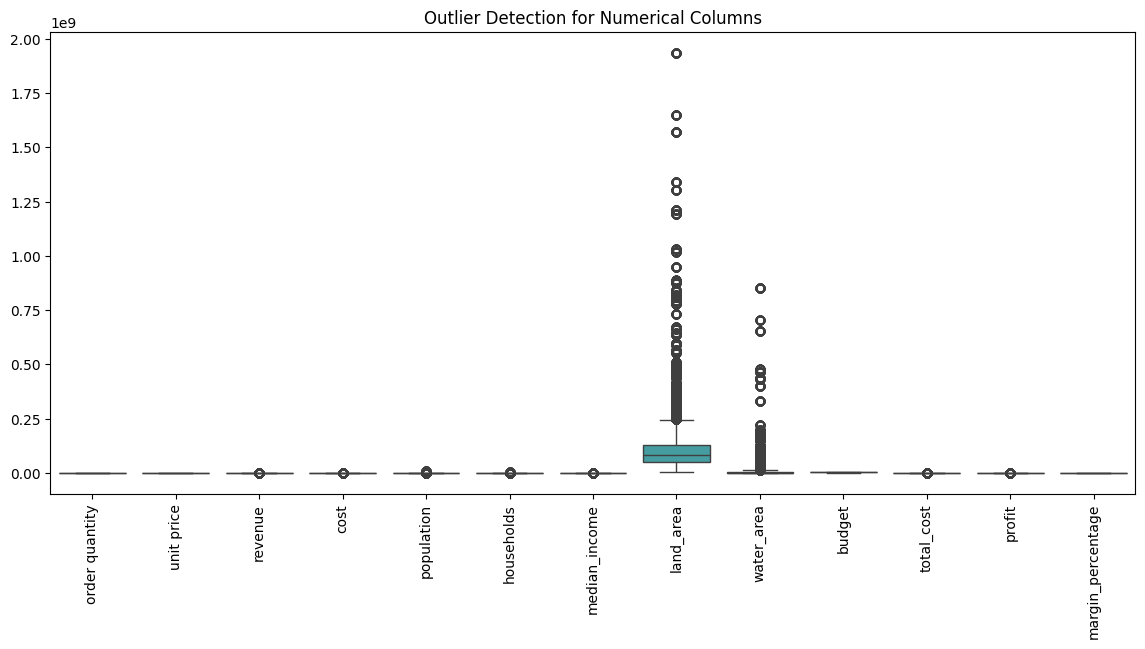

In [53]:


# select numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns

# remove columns not useful for outlier analysis
exclude = ['ordernumber','latitude','longitude','area_code']
num_cols = [col for col in num_cols if col not in exclude]

# plot outliers
plt.figure(figsize=(14,6))
sns.boxplot(data=df[num_cols])

plt.xticks(rotation=90)
plt.title("Outlier Detection for Numerical Columns")
plt.show()

In [54]:
import numpy as np

# select numeric columns
num_cols = df.select_dtypes(include=[np.number]).columns

outlier_summary = {}

for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    outlier_summary[col] = len(outliers)

print(outlier_summary)

{'order quantity': 0, 'unit price': 0, 'revenue': 2208, 'cost': 1902, 'latitude': 0, 'longitude': 0, 'area_code': 0, 'population': 6941, 'households': 7118, 'median_income': 1138, 'land_area': 6775, 'water_area': 8804, 'budget': 0, 'total_cost': 2694, 'profit': 3180, 'margin_percentage': 0}


In [55]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

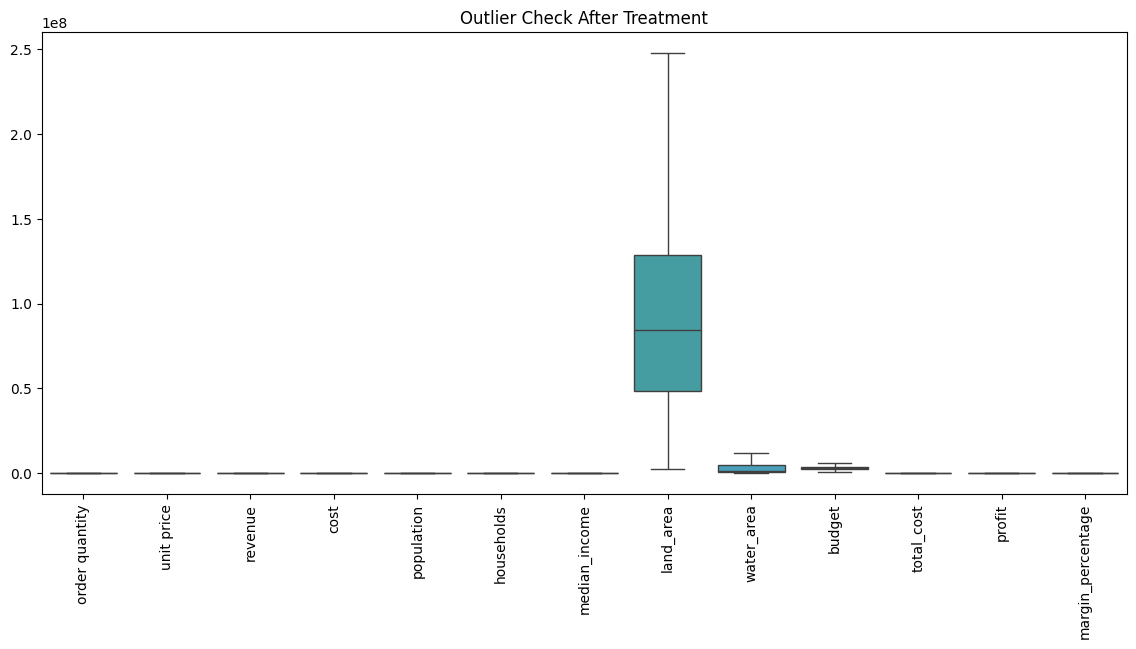

In [56]:


# select numeric columns again
num_cols = df.select_dtypes(include=[np.number]).columns

# remove columns that should not be checked
exclude = ['ordernumber','latitude','longitude','area_code']
num_cols = [col for col in num_cols if col not in exclude]

# plot again to verify outliers
plt.figure(figsize=(14,6))
sns.boxplot(data=df[num_cols])

plt.xticks(rotation=90)
plt.title("Outlier Check After Treatment")
plt.show()

# EDA

In [57]:
# Monthly sales trend over time 
# detect analysis 


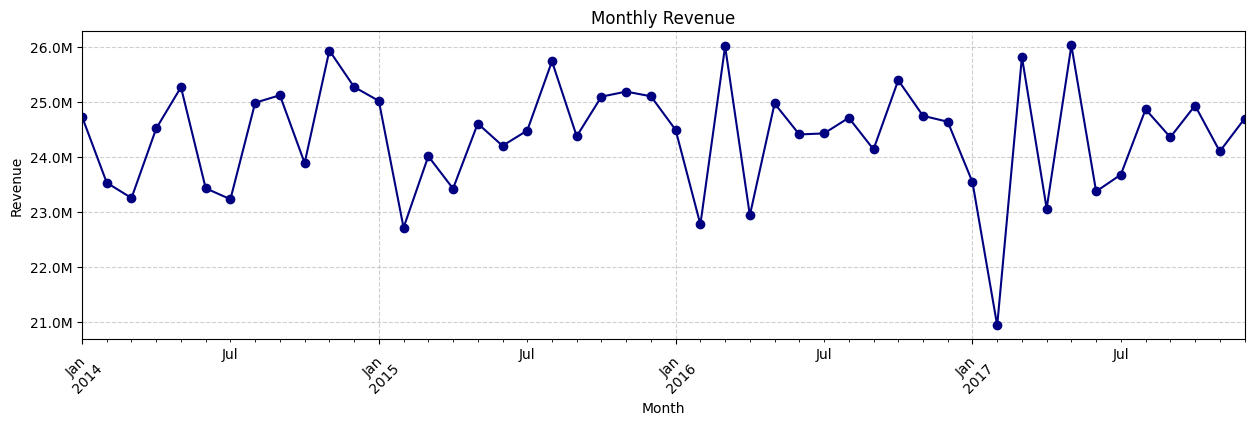

In [58]:
from matplotlib.ticker import FuncFormatter

# convert orderdate to datetime
df['orderdate'] = pd.to_datetime(df['orderdate'])

# Remove Jan and Feb 2018
df_filtered = df[
    ~((df['orderdate'].dt.year == 2018) &
      (df['orderdate'].dt.month.isin([1,2])))
].copy()

# create month column
df_filtered['order_month'] = df_filtered['orderdate'].dt.to_period('M')

# group by month
monthly_sales = df_filtered.groupby('order_month')['revenue'].sum()

# plot
plt.figure(figsize=(15,4))
monthly_sales.plot(marker='o', color='navy')

# format y-axis in millions
formatter = FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M')
plt.gca().yaxis.set_major_formatter(formatter)

plt.title("Monthly Revenue")
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [59]:
df.columns

Index(['ordernumber', 'orderdate', 'channel', 'currency code',
       'warehouse code', 'order quantity', 'unit price', 'revenue', 'cost',
       'customer names', 'product name', 'name', 'county', 'state_code',
       'state', 'type', 'latitude', 'longitude', 'area_code', 'population',
       'households', 'median_income', 'land_area', 'water_area', 'time_zone',
       'state', 'region', 'budget', 'total_cost', 'profit',
       'margin_percentage'],
      dtype='str')

In [60]:
df['orderdate'].value_counts()

orderdate
2017-10-07    67
2016-12-20    63
2015-10-20    61
2016-06-20    61
2014-11-09    60
              ..
2016-04-25    26
2014-03-02    25
2014-03-06    25
2017-08-31    25
2015-03-21    24
Name: count, Length: 1520, dtype: int64

In [61]:
dir(df['orderdate'].dt)

['__annotations__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__frozen',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_accessors',
 '_add_delegate_accessors',
 '_constructor',
 '_delegate_method',
 '_delegate_property_get',
 '_delegate_property_set',
 '_dir_additions',
 '_dir_deletions',
 '_freeze',
 '_get_values',
 '_hidden_attrs',
 '_parent',
 '_reset_cache',
 'as_unit',
 'ceil',
 'date',
 'day',
 'day_name',
 'day_of_week',
 'day_of_year',
 'dayofweek',
 'dayofyear',
 'days_in_month',
 'daysinmonth',
 'floor',
 'freq',
 'hour',
 'is_leap_year',
 'is_month_end',
 'is_month_start',
 'is_quarter_end',
 'is_quarter_start',
 'is_year_end',
 'is

In [62]:
from matplotlib.markers import MarkerStyle

print(list(reversed(MarkerStyle.markers)))

['', ' ', 'none', 'None', 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0, 'X', 'P', '_', '|', 'd', 'D', 'x', '+', 'H', 'h', '*', 'p', 's', '8', '4', '3', '2', '1', '>', '<', '^', 'v', 'o', ',', '.']


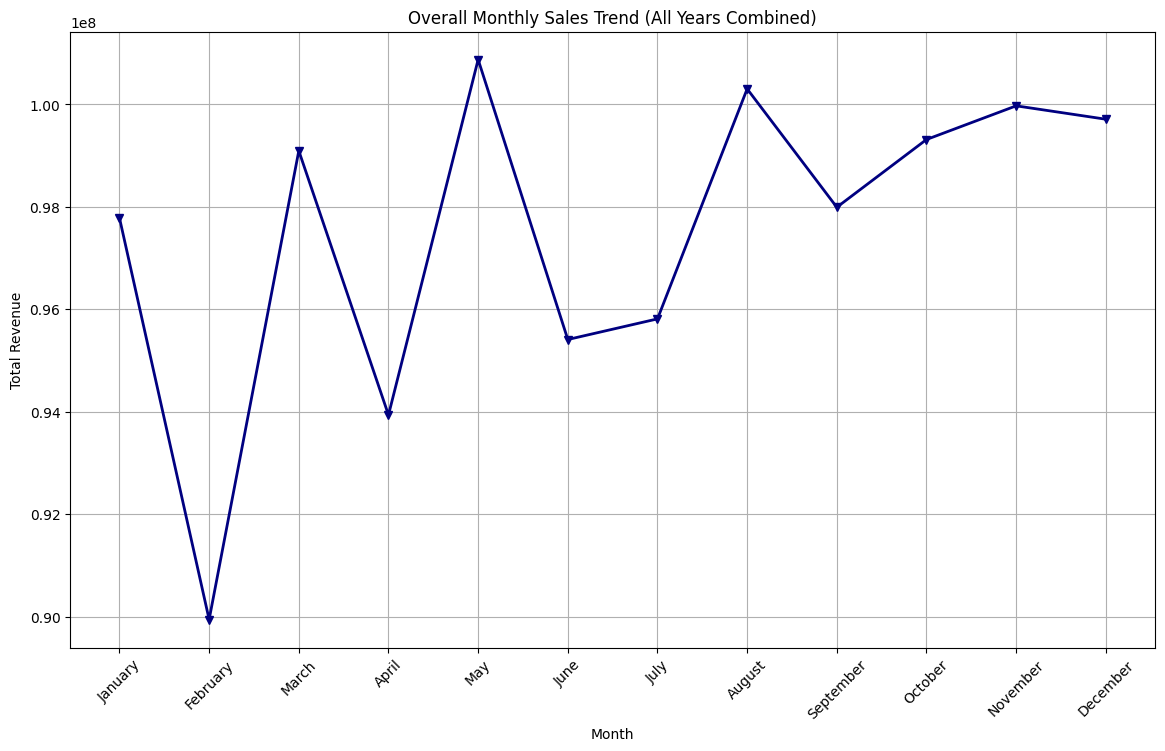

In [92]:


# Remove all 2018 records
df_filtered = df[df['orderdate'].dt.year != 2018].copy()

# Extract month name and number
df_filtered['order_month_name'] = df_filtered['orderdate'].dt.month_name()
df_filtered['order_month_num'] = df_filtered['orderdate'].dt.month

# Group by month
monthly_sales = df_filtered.groupby(
    ['order_month_num','order_month_name']
)['revenue'].sum().reset_index()

# Sort months correctly
monthly_sales = monthly_sales.sort_values('order_month_num')

# Plot
plt.figure(figsize=(14,8))

plt.plot(
    monthly_sales['order_month_name'],
    monthly_sales['revenue'],
    marker='v',
    linewidth=2,
    color='navy'
)

plt.title("Overall Monthly Sales Trend (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.grid(True)

plt.show()

The monthly sales trend reveals a clear seasonal pattern in revenue performance. Sales experience a noticeable decline in February, followed by a strong recovery in March and peak performance in May.
 After a moderate mid-year stabilization, revenue increases again in August and remains strong through the final quarter, with November and December maintaining high sales levels.

Overall, the trend indicates consistent demand throughout the year with identifiable peak and low periods, providing opportunities to optimize marketing campaigns, 
inventory planning, and sales strategies during weaker months such as February while maximizing performance during high-demand periods like May and the year-end season.

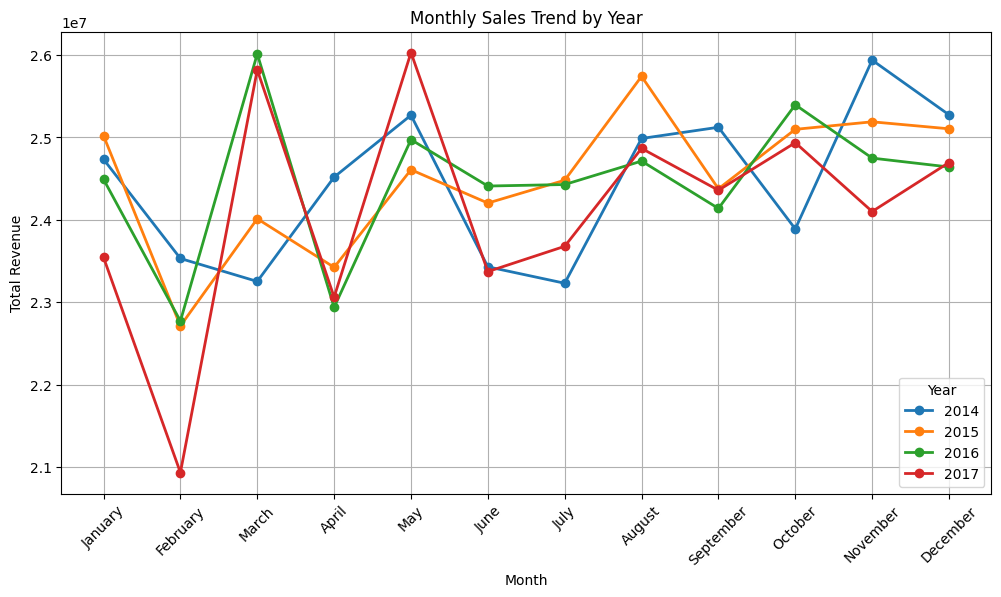

In [64]:
# Remove all 2018 records
df_filtered = df[df['orderdate'].dt.year != 2018]

# Extract year, month name, and month number
df_filtered['order_year'] = df_filtered['orderdate'].dt.year
df_filtered['order_month_name'] = df_filtered['orderdate'].dt.month_name()
df_filtered['order_month_num'] = df_filtered['orderdate'].dt.month

# Group by year and month
monthly_sales = df_filtered.groupby(
    ['order_year', 'order_month_num', 'order_month_name']
)['revenue'].sum().reset_index()

# Sort correctly
monthly_sales = monthly_sales.sort_values(['order_year', 'order_month_num'])

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Plot each year separately
for year in monthly_sales['order_year'].unique():
    
    data = monthly_sales[monthly_sales['order_year'] == year]
    
    plt.plot(
        data['order_month_name'],
        data['revenue'],
        marker='o',
        linewidth=2,
        label=year
    )

plt.title("Monthly Sales Trend by Year")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.legend(title="Year")
plt.grid(True)

plt.show()

“From this analysis, we can see that revenue remains relatively stable throughout the years with predictable monthly fluctuations.
 However, February consistently shows lower sales compared to other months, while months like March, August, October, 
 and November tend to perform better. This suggests a clear seasonal pattern in customer demand.

From a business perspective, this means we should focus on strengthening sales strategies during weaker months such as February through targeted promotions, marketing campaigns, or special offers.
At the same time, 
we should ensure sufficient inventory, staffing, and operational readiness during high-performing months to fully capture the higher demand. 
By addressing low-performance periods and maximizing strong months,
the company can achieve more consistent revenue growth throughout the year.

All years combined → BIG revenue → 1e8
Per year revenue → smaller → 1e7
1e7 = 1 × 10⁷  1e7 is scientific notation
1e7 = 10,000,000   

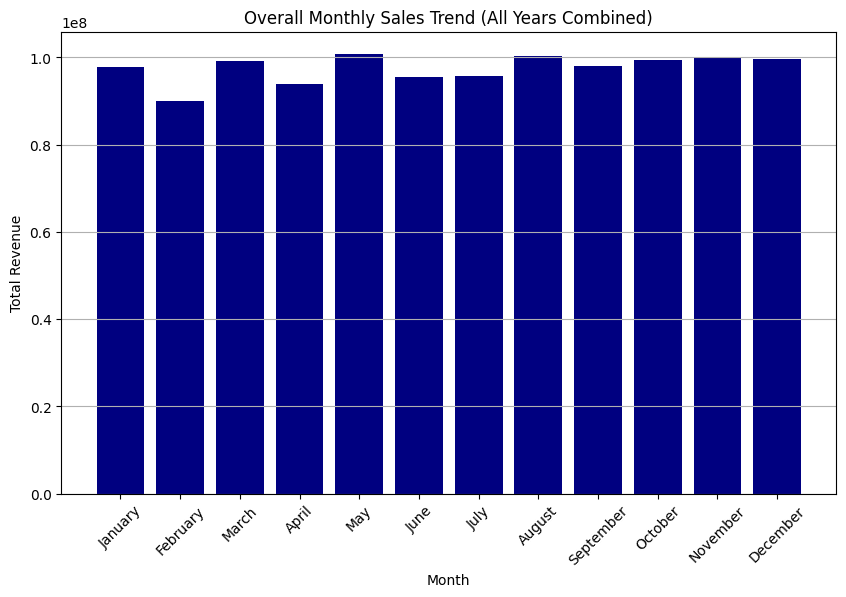

In [65]:


# Remove all 2018 records
df_filtered = df[df['orderdate'].dt.year != 2018].copy()

# Extract month name from orderdate
df_filtered['order_month_name'] = df_filtered['orderdate'].dt.month_name()

# Extract month number from orderdate
df_filtered['order_month_num'] = df_filtered['orderdate'].dt.month

# Group by month and calculate total revenue
monthly_sales = df_filtered.groupby(
    ['order_month_num', 'order_month_name']
)['revenue'].sum().reset_index()

# Sort months in chronological order
monthly_sales = monthly_sales.sort_values('order_month_num')

plt.figure(figsize=(10,6))

plt.bar(
    monthly_sales['order_month_name'],
    monthly_sales['revenue'],
    color='navy'
)

plt.title("Overall Monthly Sales Trend (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

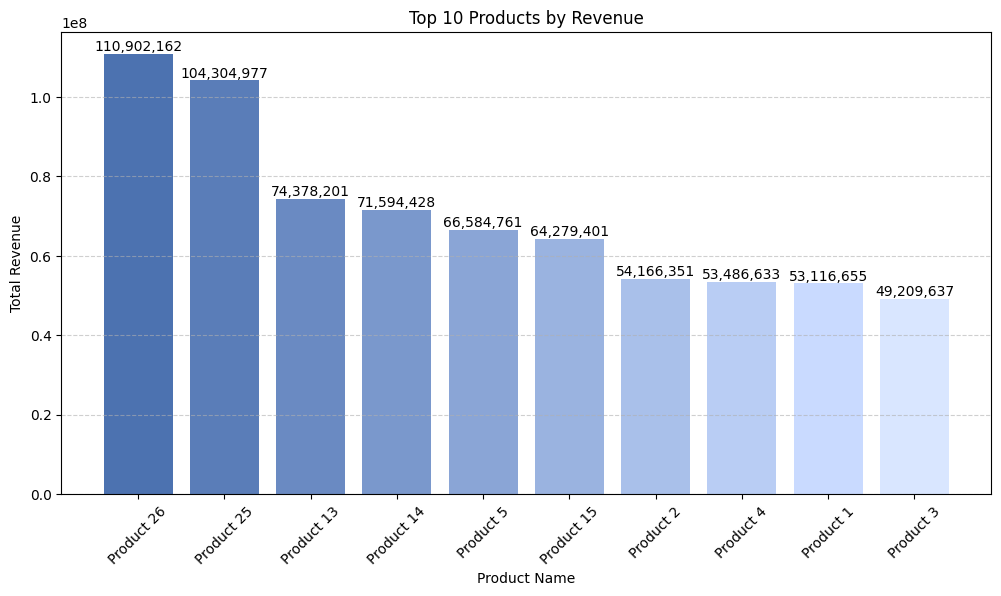

In [66]:


# Remove Jan 2018 and Feb 2018
df_filtered = df[~((df['orderdate'].dt.year == 2018) & (df['orderdate'].dt.month.isin([1,2])))]

# Step 1: Calculate total revenue per product
top_products = df_filtered.groupby('product name')['revenue'].sum().reset_index()

# Step 2: Sort by revenue (highest first)
top_products = top_products.sort_values(by='revenue', ascending=False)

# Step 3: Select top 10 products
top_products = top_products.head(10)

# Step 4: Soft sales-style colors
colors = [
'#4C72B0','#5A7DB8','#6A8AC2','#7A98CC','#8AA5D6',
'#9AB3E0','#A9C0EA','#B9CDF4','#C9DAFF','#D9E6FF'
]

# Step 5: Plot bar chart
plt.figure(figsize=(12,6))

bars = plt.bar(
    top_products['product name'],
    top_products['revenue'],
    color=colors
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Name")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Step 6: Add labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.show()

The chart shows the top 10 products ranked by total revenue. From the analysis, Product 26 generates the highest revenue (about 110.9M), followed closely by Product 25 (about 104.3M).
 These two products clearly stand out as the major revenue contributors.

The next group — Product 13, Product 14, Product 5, and Product 15 — generates revenue between 64M and 74M, indicating moderately strong performance. 
The remaining products — Product 2, Product 4, Product 1, and Product 3 — generate relatively lower revenue within the top 10, ranging from 49M to 54M.

From a data analysis perspective, the revenue distribution is not uniform across products, with a noticeable gap between the top two products and the rest. 
This suggests that a small number of products contribute a large share of total revenue, indicating revenue concentration.

From a business perspective, these findings highlight the importance of Product 26 and Product 25 as key revenue drivers. 
The company should ensure strong inventory management, marketing focus, and supply chain support for these high-performing products to maintain revenue stability. 
Additionally, analyzing the strategies behind these successful products could help improve the performance of lower-ranked products.

The analysis shows that revenue is concentrated among a few top-performing products, with Product 26 and Product 25 generating the highest revenue compared to the others. 

While several products contribute moderately to overall sales, the top products play a critical role in driving the company’s revenue. From a business perspective, 

the company should prioritize maintaining strong supply, marketing, and customer engagement for these key products while exploring strategies to improve the performance of lower-revenue products to achieve more balanced revenue growth

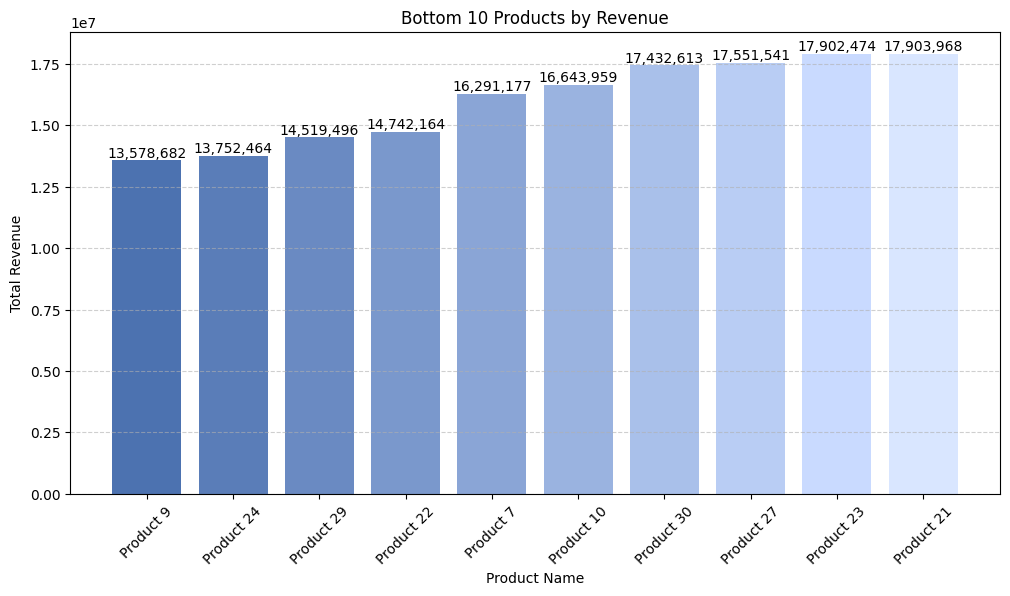

In [67]:


# Remove Jan 2018 and Feb 2018
df_filtered = df[~((df['orderdate'].dt.year == 2018) & (df['orderdate'].dt.month.isin([1,2])))]

# Step 1: Calculate total revenue per product
bottom_products = df_filtered.groupby('product name')['revenue'].sum().reset_index()

# Step 2: Sort by revenue (lowest first)
bottom_products = bottom_products.sort_values(by='revenue', ascending=True)

# Step 3: Select bottom 10 products
bottom_products = bottom_products.head(10)

# Step 4: Soft sales-style colors
colors = [
'#4C72B0','#5A7DB8','#6A8AC2','#7A98CC','#8AA5D6',
'#9AB3E0','#A9C0EA','#B9CDF4','#C9DAFF','#D9E6FF'
]

# Step 5: Plot bar chart
plt.figure(figsize=(12,6))

bars = plt.bar(
    bottom_products['product name'],
    bottom_products['revenue'],
    color=colors
)

plt.title("Bottom 10 Products by Revenue")
plt.xlabel("Product Name")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Step 6: Add labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.show()

The chart displays the bottom 10 products ranked by total revenue. From the analysis, Product 9 generates the lowest revenue (≈13.57M), followed by Product 24 and Product 29, which also contribute relatively low revenue compared to other products.

Most of the products in this group generate revenue between 13M and 18M, which is significantly lower than the revenue generated by the top-performing products. This indicates that these products have lower demand or weaker market performance compared to the rest of the product portfolio.

From a data analysis perspective, the revenue distribution shows a clear gap between top-performing products and the lowest-performing ones, suggesting that sales are heavily concentrated among a few high-performing products while several products contribute only a small portion to the overall revenue.

From a business perspective, these low-performing products may require further investigation to understand the reasons behind their lower sales, such as pricing, marketing effectiveness, product demand, or competition. The company may consider improving promotional strategies, adjusting pricing, or reevaluating the product strategy for these items.

The analysis indicates that these products contribute the least to total revenue, highlighting an opportunity for the business to investigate their low performance and implement strategies such as improved marketing, pricing adjustments, or product optimization to enhance their sales contribution.

In [68]:
df.columns

Index(['ordernumber', 'orderdate', 'channel', 'currency code',
       'warehouse code', 'order quantity', 'unit price', 'revenue', 'cost',
       'customer names', 'product name', 'name', 'county', 'state_code',
       'state', 'type', 'latitude', 'longitude', 'area_code', 'population',
       'households', 'median_income', 'land_area', 'water_area', 'time_zone',
       'state', 'region', 'budget', 'total_cost', 'profit',
       'margin_percentage'],
      dtype='str')

In [69]:
df['channel'].value_counts()

channel
Wholesale      34596
Distributor    19968
Export          9540
Name: count, dtype: int64

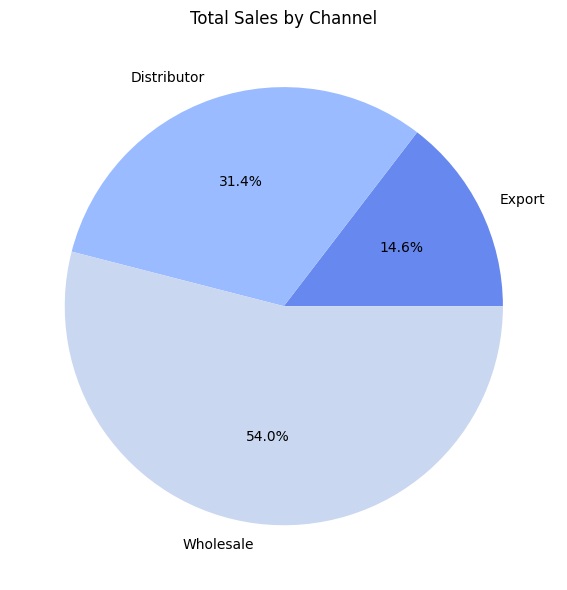

In [70]:


# Sales by channel
chan_sales = df.groupby('channel')['revenue'].sum().sort_values(ascending=True)

plt.figure(figsize=(6,6))

plt.pie(
    chan_sales.values,
    labels=chan_sales.index,
    autopct='%1.1f%%',
    colors=sns.color_palette("coolwarm")
)

plt.title("Total Sales by Channel")

plt.tight_layout()
plt.show()

The chart illustrates the distribution of total sales across different sales channels: Wholesale, Distributor, and Export. From the analysis, Wholesale contributes the largest share of total sales at approximately 54%, making it the dominant sales channel. Distributor sales account for about 31.4%, representing the second-largest contribution, while Export contributes the smallest share at around 14.6%.

From a data analysis perspective, the sales distribution indicates that the company's revenue is heavily dependent on the wholesale channel, with more than half of total sales coming from this segment. Distributor channels also play a significant role, while export sales represent a relatively smaller portion of the overall revenue.

From a business perspective, this suggests that maintaining strong relationships with wholesale partners is critical for sustaining revenue performance. At the same time, the relatively lower contribution from export sales may represent a potential growth opportunity, where the company could explore expanding into international markets or strengthening export strategies to diversify revenue sources.

The analysis shows that wholesale is the primary driver of total sales, contributing more than half of the revenue, while distributor channels provide additional support. Export sales currently represent a smaller share, indicating a potential opportunity for the business to expand and diversify its revenue streams

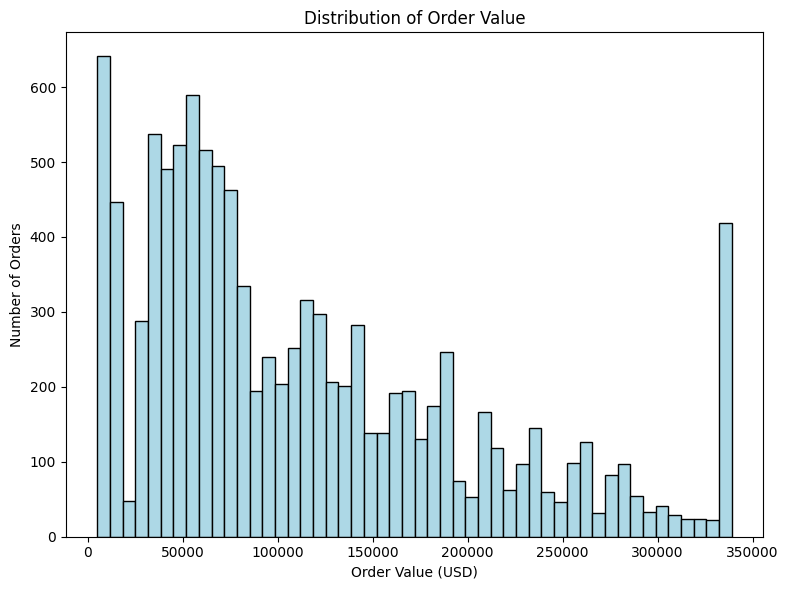

In [71]:
# average Order value distribution

aov = df.groupby("ordernumber")['revenue'].sum()

plt.figure(figsize=(8,6))

plt.hist(
    aov,
    bins=50,
    color='lightblue',
    edgecolor='black'
)

plt.title("Distribution of Order Value")
plt.xlabel("Order Value (USD)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()


The histogram shows the distribution of order values across all transactions. From the analysis, most orders are concentrated in the lower to mid-value range, approximately between $30,000 and $100,000. This indicates that the majority of customers place moderate-sized orders rather than very large purchases.

As the order value increases beyond $150,000, the number of orders gradually decreases. Only a small number of transactions fall in the high-value range above $200,000, showing that large orders occur less frequently.

From a data analysis perspective, the distribution appears right-skewed, meaning there are many smaller and medium-sized orders and fewer very large orders. These high-value transactions act as outliers but still contribute significantly to overall revenue.

From a business perspective, this suggests that the company's sales volume is largely driven by consistent mid-sized orders, while large orders, although less frequent, can significantly boost total revenue. This highlights the importance of maintaining strong relationships with key clients who place high-value orders while continuing to support the broader customer base that generates regular mid-range orders.

The order value distribution indicates that most transactions fall within the mid-value range, while high-value orders are less frequent but play an important role in increasing overall revenue. Therefore, the business should focus on sustaining regular mid-sized orders while also nurturing high-value customers to maximize revenue growthm

there is skewness  right skewed 

onthly Revenue
Overall Monthly Sales Trend (All Years Combined)
Overall Monthly Sales Trend (All Years Combined)-bar
Monthly Sales Trend by Year
Top 10 Products by Revenue
Bottom 10 Products by Revenue
Total Sales by Channe
Distribution of Order Value

In [72]:
# Unit price Distibution per product 
# top 10  state by revenue by ordercount 
# average profit margin by channel
# top and bottom 10 customer by revenue
# customer segmentation  revenue vs profit margin
# correlation  heatmap


In [73]:
# Calculate Q1 and Q3
Q1 = df['unit price'].quantile(0.25)
Q3 = df['unit price'].quantile(0.75)

# Calculate IQR
IQR = Q3 - Q1

# Define limits
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df['unit price'] < lower_bound) | (df['unit price'] > upper_bound)]

print("Number of outliers:", len(outliers))
outliers.head()

Number of outliers: 0


,ordernumber,orderdate,channel,currency code,warehouse code,order quantity,unit price,revenue,cost,customer names,...,median_income,land_area,water_area,time_zone,state,region,budget,total_cost,profit,margin_percentage


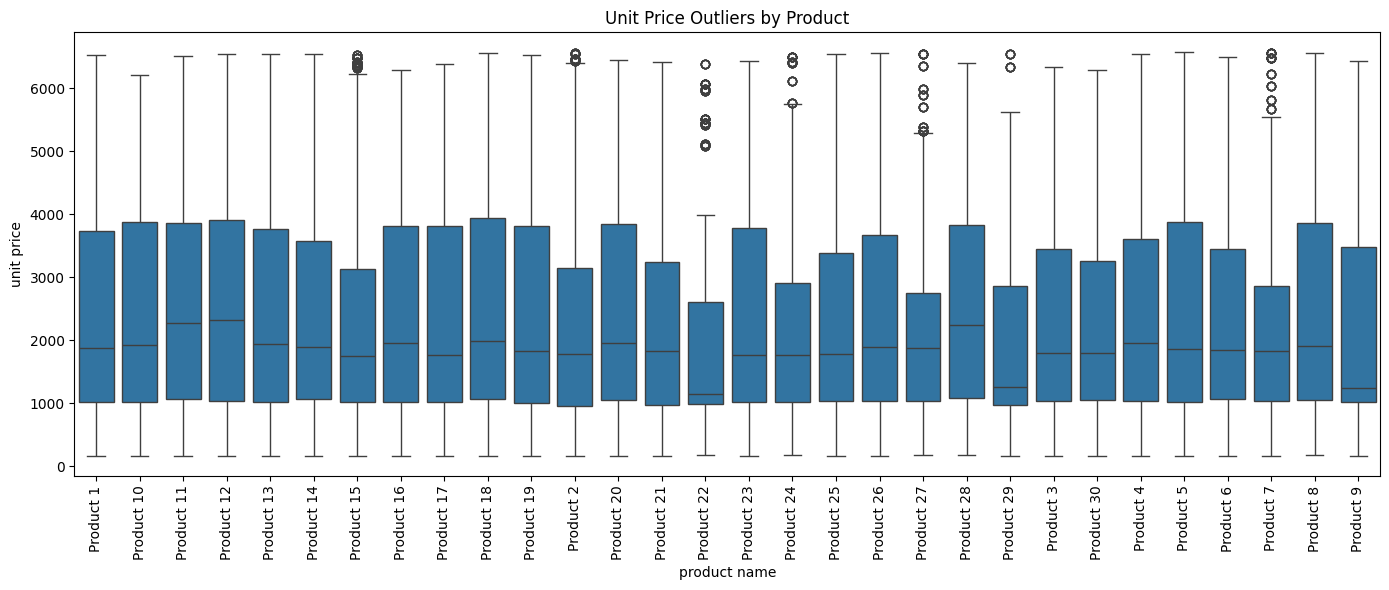

In [74]:
plt.figure(figsize=(14,6))
sns.boxplot(x='product name', y='unit price', data=df)

plt.xticks(rotation=90)
plt.title("Unit Price Outliers by Product")
plt.tight_layout()
plt.show()

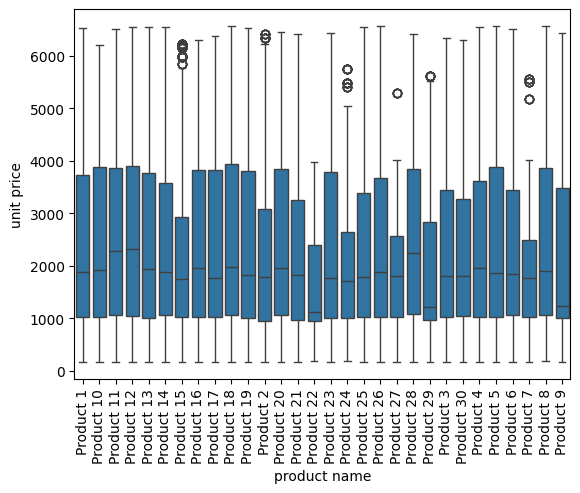

In [75]:
def remove_outliers(group):

    Q1 = group['unit price'].quantile(0.25)
    Q3 = group['unit price'].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    return group[(group['unit price'] >= lower) & (group['unit price'] <= upper)]


df_clean = (
    df.groupby('product name')
      .apply(remove_outliers)
      .reset_index(drop=False)
)
sns.boxplot(x='product name', y='unit price', data=df_clean)

plt.xticks(rotation=90)
plt.show()

C:\Users\Startklar\AppData\Local\Temp\ipykernel_22944\223987311.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


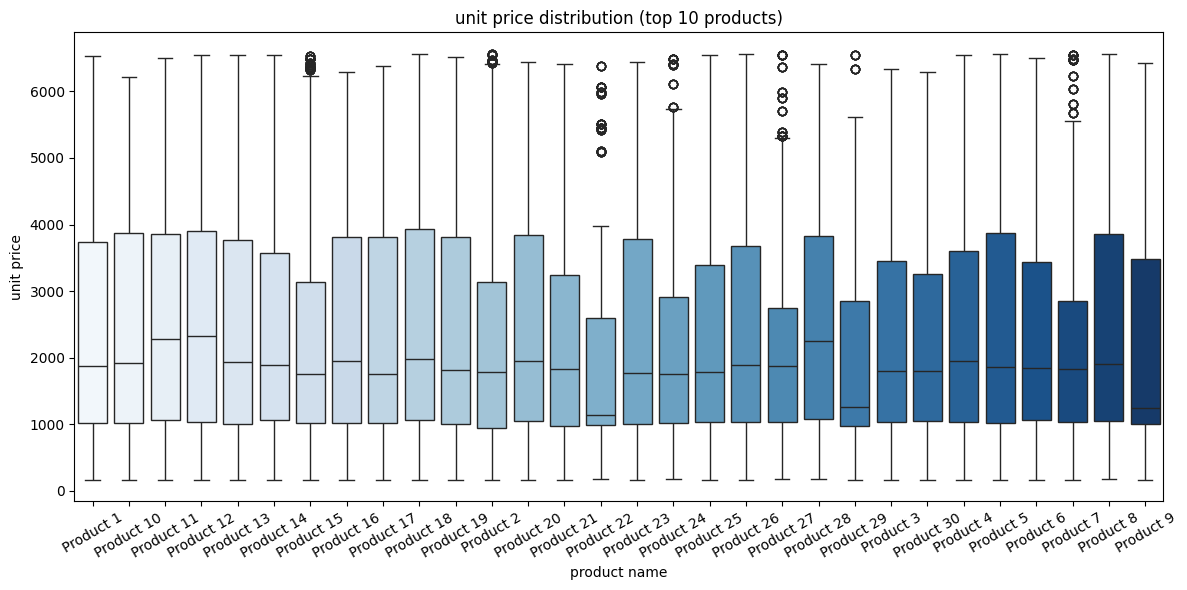

In [76]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x='product name',
    y='unit price',
    data=df,
    palette='Blues'
)

plt.xticks(rotation=30)
plt.title("unit price distribution (top 10 products)")
plt.tight_layout()

plt.show()

The boxplot illustrates the distribution of unit prices for the top 10 products. Each box represents the spread of prices for a product, including the median price, variability, and potential outliers.

From a data analysis perspective, most products show a wide range of unit prices, indicating variability in pricing across different transactions. The median prices for many products appear to fall roughly between $1,200 and $2,000, suggesting that the typical selling price for these products lies within this range. The presence of several outliers above $5,000–$6,000 indicates that some transactions involve significantly higher unit prices, which may result from premium orders, bulk pricing differences, or special deals.

Additionally, some products display larger interquartile ranges, meaning their prices fluctuate more compared to others. This could indicate variable pricing strategies, discounts, or differences in order conditions.

From a business perspective, the variation in unit prices suggests opportunities to review pricing consistency across products. Products with higher median prices or frequent high-value outliers may represent premium offerings, while products with wider variability may benefit from more standardized pricing strategies.

The analysis shows that unit prices vary considerably across products, with most transactions occurring within a moderate price range while occasional high-price outliers contribute additional revenue. This suggests the importance of monitoring pricing strategies to ensure consistency while maximizing revenue from premium transactions

In [77]:
df.columns

Index(['ordernumber', 'orderdate', 'channel', 'currency code',
       'warehouse code', 'order quantity', 'unit price', 'revenue', 'cost',
       'customer names', 'product name', 'name', 'county', 'state_code',
       'state', 'type', 'latitude', 'longitude', 'area_code', 'population',
       'households', 'median_income', 'land_area', 'water_area', 'time_zone',
       'state', 'region', 'budget', 'total_cost', 'profit',
       'margin_percentage'],
      dtype='str')

In [78]:
for i, col in enumerate(df.columns):
    if col == 'state':
        print(i, col)

14 state
25 state


In [79]:
df.iloc[:,14].head()
df.iloc[:,25].head()

0        Georgia
1        Indiana
2     California
3        Indiana
4    Connecticut
Name: state, dtype: category
Categories (47, str): ['Alabama', 'Arizona', 'Arkansas', 'California', ..., 'Virginia', 'Washington', 'Wisconsin', 'Wyoming']

In [80]:
df = df.loc[:, ~df.columns.duplicated()]

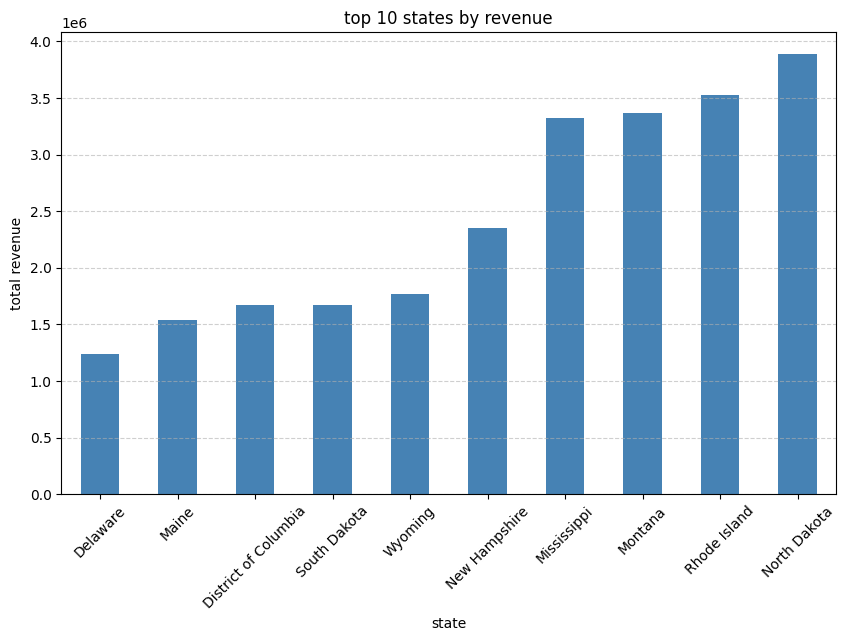

In [81]:
top_states =  df.groupby('state')['revenue'].sum().sort_values(ascending=True).head(10)

plt.figure(figsize=(10,6))
top_states.plot(kind='bar', color='steelblue')

plt.title("top 10 states by revenue")
plt.xlabel("state")
plt.ylabel("total revenue")

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

The bar chart shows the top 10 states contributing the highest revenue. From the analysis, North Dakota generates the highest revenue, followed by Rhode Island and Montana, indicating that these states are the strongest revenue-performing regions. Other states such as Mississippi and New Hampshire also contribute significantly, while Delaware and Maine generate comparatively lower revenue within the top 10 group.

From a data analysis perspective, there is a noticeable variation in revenue across states, with revenue ranging roughly from about 1.2 million to nearly 3.9 million. This indicates that sales performance is not evenly distributed geographically, and certain states contribute more strongly to the overall revenue.

From a business perspective, the states generating higher revenue may represent key markets with strong demand, better distribution networks, or higher customer activity. These regions could be prioritized for continued investment, marketing efforts, and inventory availability. At the same time, states with comparatively lower revenue within the top group may offer opportunities for market expansion and targeted sales strategies to increase their contribution.

The analysis shows that revenue performance varies across states, with North Dakota, Rhode Island, and Montana emerging as the strongest markets. This suggests that focusing on high-performing regions while implementing growth strategies in moderately performing states could help improve overall revenue distribution

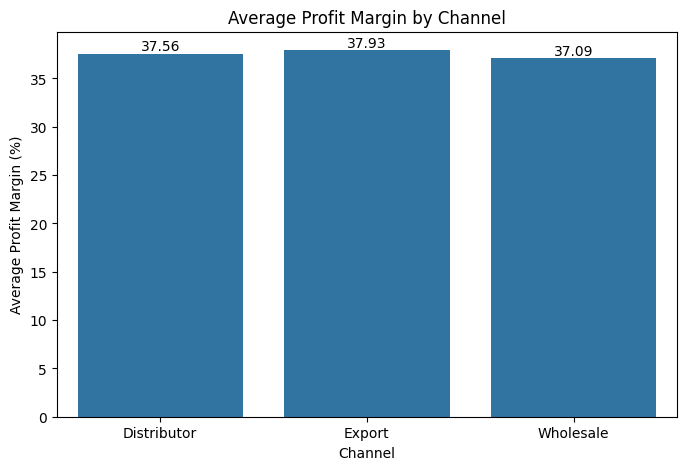

In [82]:
plt.figure(figsize=(8,5))

avg_margin = df.groupby('channel')['margin_percentage'].mean().reset_index()

ax = sns.barplot(data=avg_margin, x='channel', y='margin_percentage')

plt.title('Average Profit Margin by Channel')
plt.xlabel('Channel')
plt.ylabel('Average Profit Margin (%)')

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.show()

The bar chart presents the average profit margin across different sales channels: Distributor, Export, and Wholesale. From the analysis, all three channels show very similar profit margins, ranging between about 37% and 38%.

Among them, the Export channel has the highest average profit margin at approximately 37.93%, followed by Distributor at around 37.56%, while Wholesale has the slightly lower margin at about 37.09%. However, the difference between these channels is relatively small, indicating that profitability is fairly consistent across all sales channels.

From a data analysis perspective, this suggests that the company's pricing and cost structures are well balanced across different distribution channels, with no channel significantly outperforming or underperforming in terms of profitability.

From a business perspective, while Wholesale may generate larger sales volume, the Export channel provides slightly higher profit margins, which may present an opportunity to expand export activities for improved profitability. At the same time, maintaining strong distributor relationships remains important to sustain consistent revenue and profit levels.

The analysis shows that profit margins are relatively consistent across all sales channels, with Export generating the highest margin and Wholesale slightly lower. This suggests stable profitability across channels while highlighting potential opportunities to expand higher-margin channels to further enhance overall profitability.”

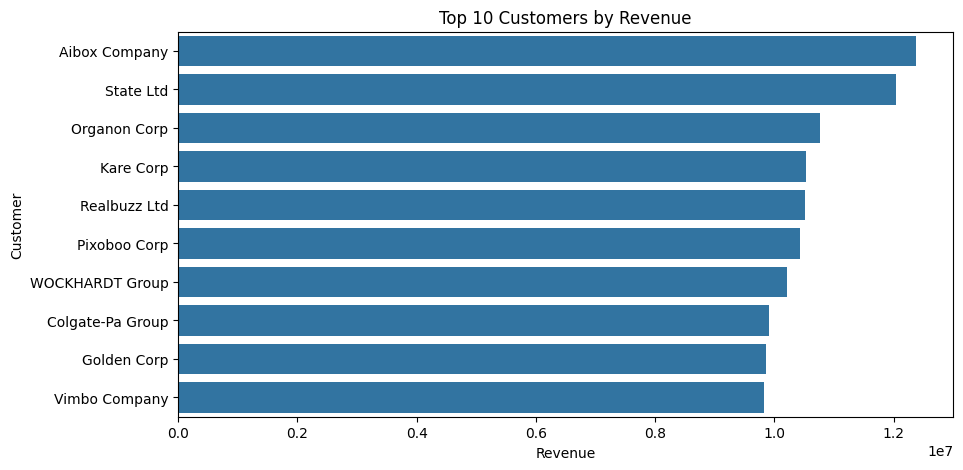

In [83]:
top_customers = df.groupby('customer names')['revenue'].sum().nlargest(10).reset_index()

plt.figure(figsize=(10,5))

sns.barplot(data=top_customers, x='revenue', y='customer names')

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Customer')

plt.show()

The chart shows the top 10 customers contributing the highest revenue to the company. From the analysis, Aibox Company generates the highest revenue, followed by State Ltd and Organon Corp, indicating that these customers are the largest contributors to the company’s sales.

Other customers such as Kare Corp, Realbuzz Ltd, and Pixoboo Corp also contribute significant revenue, while Golden Corp and Vimbo Company generate slightly lower revenue within the top 10 group. However, the difference between customers is relatively moderate, suggesting that revenue among the top customers is fairly competitive and distributed across several key accounts.

From a data analysis perspective, this indicates that the company’s revenue is partially concentrated among a small group of high-value customers, which play an important role in overall business performance.

From a business perspective, maintaining strong relationships with these key customers is crucial for sustaining revenue stability. The company may focus on customer retention strategies, personalized services, and long-term contracts to ensure continued business from these high-value clients.

The analysis shows that a small group of key customers contributes a significant portion of the company’s revenue, with Aibox Company and State Ltd leading the list. Strengthening relationships with these high-value customers will be important for maintaining stable revenue and long-term business growth

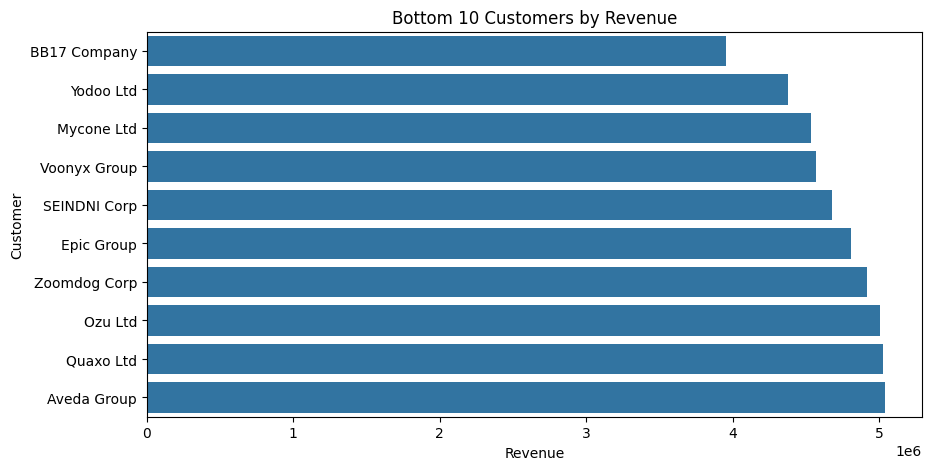

In [84]:
bottom_customers = df.groupby('customer names')['revenue'].sum().nsmallest(10).reset_index()

plt.figure(figsize=(10,5))

sns.barplot(data=bottom_customers, x='revenue', y='customer names')

plt.title('Bottom 10 Customers by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Customer')

plt.show()

The chart displays the bottom 10 customers contributing the least revenue to the company. From the analysis, BB17 Company generates the lowest revenue, followed by Yodoo Ltd and Mycone Ltd, indicating that these customers contribute the smallest share of sales among the listed customers.

The remaining customers such as Voonxy Group, SEINDNI Corp, and Epic Group generate slightly higher revenue within this group, while Aveda Group and Quaxo Ltd are at the upper end of the bottom 10 customers. Overall, the revenue among these customers ranges roughly between about 4 million and 5 million, which is significantly lower compared to the top customers.

From a data analysis perspective, this indicates that customer revenue contribution varies significantly, with a clear gap between high-value customers and lower-value customers.

From a business perspective, these lower-performing customers may represent opportunities for growth through targeted marketing, promotions, or improved engagement strategies. Strengthening relationships with these customers could help increase their purchasing volume and improve their contribution to overall revenue

The analysis shows that these customers contribute the least to overall revenue, highlighting an opportunity for the business to implement targeted strategies to increase engagement and sales from these lower-performing customer segments.

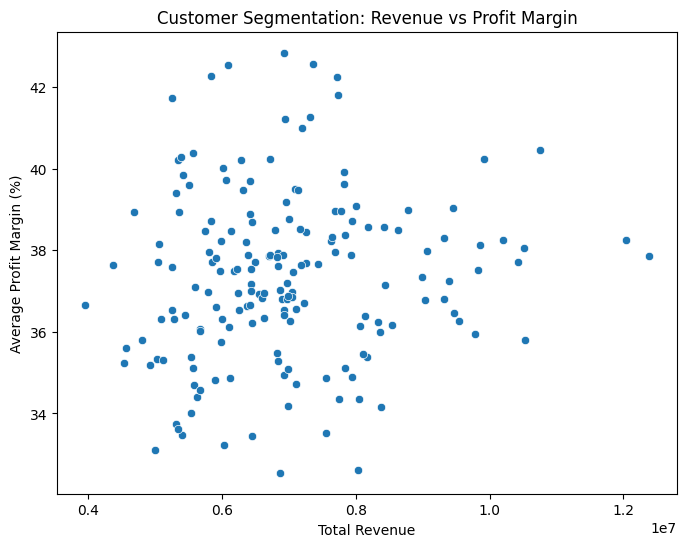

In [85]:
customer_seg = df.groupby('customer names').agg({
    'revenue':'sum',
    'margin_percentage':'mean'
}).reset_index()

plt.figure(figsize=(8,6))

sns.scatterplot(data=customer_seg,
                x='revenue',
                y='margin_percentage')

plt.title('Customer Segmentation: Revenue vs Profit Margin')
plt.xlabel('Total Revenue')
plt.ylabel('Average Profit Margin (%)')

plt.show()

The scatter plot shows the relationship between total revenue generated by customers and their average profit margin. Each point represents a customer, with revenue on the x-axis and profit margin on the y-axis.

From a data analysis perspective, most customers generate revenue between about 5M and 9M, with profit margins generally ranging between 35% and 39%. The points are fairly scattered, indicating that higher revenue does not always correspond to higher profit margins. Some customers generate high revenue but have moderate profit margins, while others generate lower revenue but maintain relatively higher margins.

Additionally, a few customers appear on the higher revenue side (above 10M), showing that these are high-value customers, although their profit margins remain within a similar range as other customers.

From a business perspective, this suggests that while some customers contribute significantly to revenue, they do not necessarily generate the highest profitability. Therefore, the company should focus on balancing both revenue and profit margin when evaluating customer value. High-revenue customers should be maintained through strong relationships, while customers with higher profit margins may present opportunities for profit optimization strategies.

The analysis shows that customer revenue and profit margin do not have a strong direct relationship, indicating that some high-revenue customers may generate moderate margins while others provide higher profitability. This highlights the importance of balancing both revenue growth and profit margin when managing customer relationships and business strategy

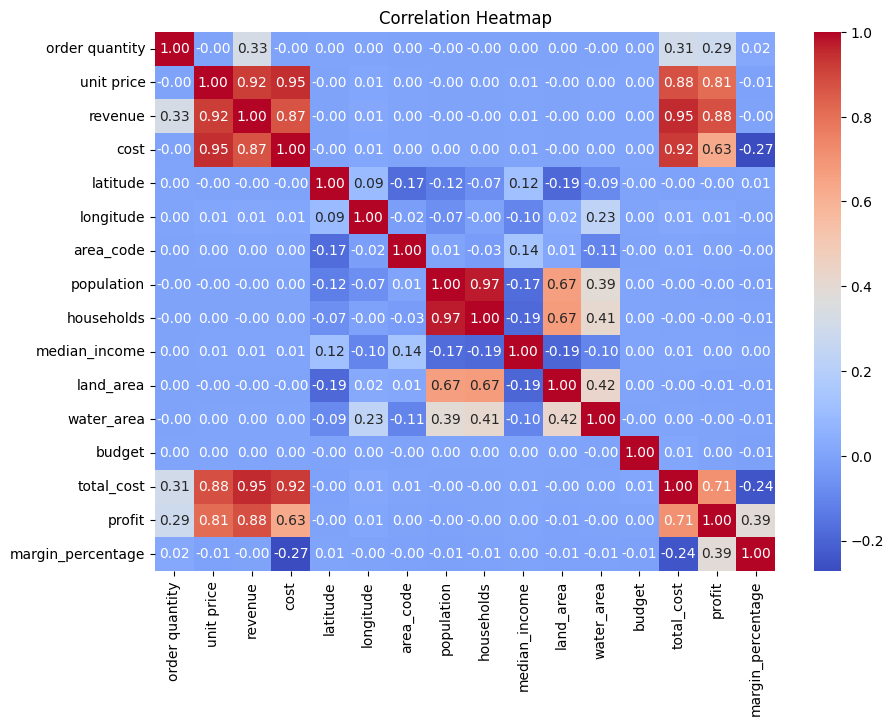

In [86]:
plt.figure(figsize=(10,7))

numeric_cols = df.select_dtypes(include='number')

sns.heatmap(numeric_cols.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')

plt.show()


The correlation heatmap shows the relationships between key numerical variables such as order quantity, unit price, revenue, cost, profit, and other regional or demographic variables.

From a data analysis perspective, several strong correlations are visible:

Revenue has a very strong positive correlation with unit price (≈0.92) and cost (≈0.87), indicating that higher-priced products and higher costs are associated with higher revenue generation.

Total cost also shows a strong correlation with revenue (≈0.95), which suggests that as sales increase, overall operational costs also rise.

Profit is strongly correlated with revenue (≈0.88), meaning that increased sales generally lead to higher profits.

Population and households show a very strong correlation (≈0.97), which is expected since regions with higher populations typically have more households.

At the same time, profit margin percentage shows weaker correlations with most variables, indicating that profitability efficiency is influenced by multiple factors rather than a single variable.

From a business perspective, these relationships highlight that revenue growth is largely driven by pricing and sales volume, while costs increase alongside revenue. This means the company should focus not only on increasing revenue but also on managing operational costs efficiently to maintain strong profit margins. Additionally, demographic variables such as population may help identify potential high-demand markets for expansion.

The correlation analysis shows that revenue, unit price, cost, and profit are strongly interconnected, indicating that pricing and sales performance are key drivers of business growth. However, maintaining profitability requires careful cost management while leveraging high-demand markets identified through demographic factors

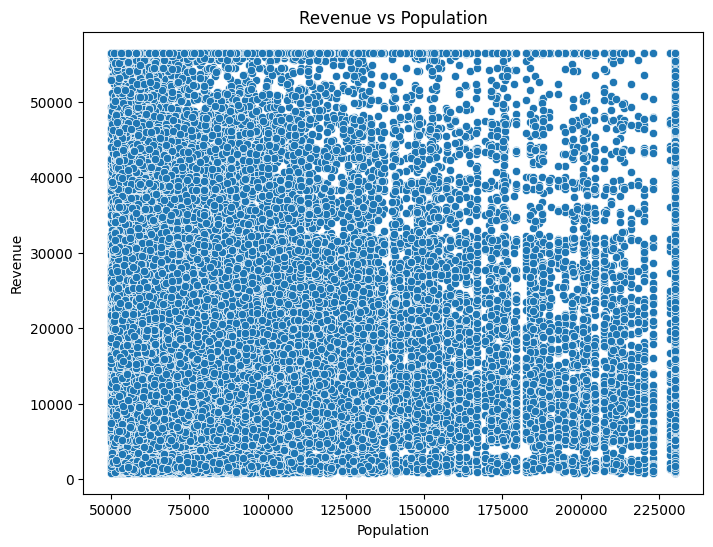

In [87]:

plt.figure(figsize=(8,6))

sns.scatterplot(data=df, x='population', y='revenue')

plt.title('Revenue vs Population')
plt.xlabel('Population')
plt.ylabel('Revenue')

plt.show()

The scatter plot shows the relationship between population size and revenue across different regions or markets. Each point represents a location, with population on the x-axis and revenue on the y-axis.

From a data analysis perspective, the data points are widely scattered across the plot, indicating no strong linear relationship between population and revenue. Revenue values vary significantly even within similar population ranges. This means that areas with larger populations do not necessarily generate proportionally higher revenue compared to smaller populations.

Although some higher-population regions show moderate revenue levels, the overall distribution suggests that population alone is not a strong predictor of revenue performance. Other factors such as customer demand, purchasing power, market penetration, pricing strategies, and competition may play a more important role.

From a business perspective, this indicates that simply targeting regions with larger populations may not guarantee higher sales. Instead, the company should focus on market potential, customer behavior, and economic factors when identifying profitable markets and planning expansion strategies.

The analysis suggests that population size alone does not strongly influence revenue generation. Therefore, business growth strategies should focus on understanding customer demand, market conditions, and purchasing behavior rather than relying solely on population size

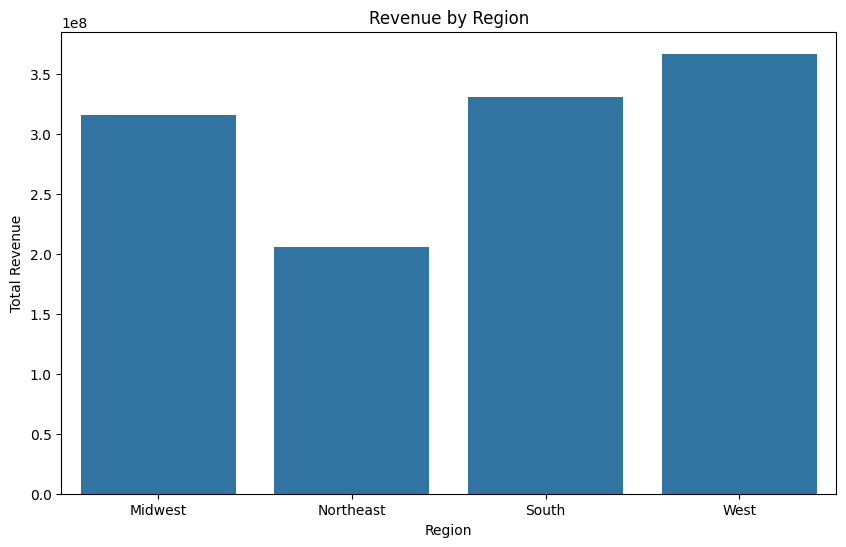

In [88]:
plt.figure(figsize=(10,6))

region_sales = df.groupby('region')['revenue'].sum().reset_index()

sns.barplot(data=region_sales, x='region', y='revenue')

plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue')

plt.show()

The bar chart illustrates the total revenue generated across different regions: Midwest, Northeast, South, and West.

From a data analysis perspective, the West region generates the highest revenue, followed by the South and Midwest regions, while the Northeast region records the lowest revenue among the four regions. The difference in revenue between regions indicates that sales performance varies geographically, with some regions contributing more strongly to the company’s overall revenue.

The West and South regions show particularly strong performance, suggesting higher customer demand, stronger market presence, or better distribution networks in these areas.

From a business perspective, these results highlight that the West and South regions are key revenue-driving markets and should continue to receive strong operational support, marketing investment, and inventory availability. At the same time, the Northeast region presents a potential opportunity for growth, where targeted marketing strategies or improved distribution efforts could help increase sales performance.

The analysis indicates that revenue performance varies across regions, with the West and South emerging as the strongest markets. Strengthening operations in high-performing regions while implementing growth strategies in lower-performing regions like the Northeast could help improve overall revenue balance

**Final Overall Conclusion**

The analysis shows that the company’s sales are largely driven by a small number of high-performing products, key customers, and strong regions. These factors contribute significantly to the overall revenue and play an important role in the company’s business performance.

Most orders fall within a moderate value range, while a smaller number of high-value orders contribute a noticeable portion of total revenue. The results also show that unit price, revenue, cost, and profit are closely related, meaning that pricing strategies and sales volume have a strong impact on profitability.

Regional analysis indicates that some regions perform better than others, suggesting differences in market demand and business opportunities. At the same time, a few products, customers, and regions contribute less revenue, which highlights potential areas where the company can improve its sales strategies.

Overall, the company should continue focusing on its top-performing products, valuable customers, and strong markets while developing strategies to improve lower-performing segments. This approach will help the business achieve more stable revenue growth and better overall performance.

In [89]:
df.to_csv("regional_sales.csv", index=False)